In [1]:
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from matplotlib import font_manager
from glob import glob
import os
import json
import seaborn as sns
import pandas as pd
from collections import Counter

font_path = 'Futura Book.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path, size='large')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams.update({'font.size': 16})

In [2]:
stacked = []
for path in glob("./data/*/amplitudes/*json"):
    splitpath = path.split("/")
    basis = splitpath[2]
    name = splitpath[-1].split('_')[2]
    with open(path,'r') as f:
        metrics = json.load(f)
    
    
    gendf = pd.DataFrame.from_dict(metrics['amplitude_generation_times'],orient='index').rename(columns={0:'amplitude_generation_times'})
    metricdf = pd.DataFrame.from_dict(metrics['metrics'],orient='index').rename(columns={0:'metrics'})
    metricdf.loc['t2',metricdf.columns] = 0
    gendf = gendf.rename(index={'Zeroes':'t2_zeroes', 'Random':'t2_rand', 'MP2*':'t2_MP2', "ML":'t2_ML',"Exact":'t2', 'ML_exact':'t2_ML_exact'})

    joined = pd.concat([metricdf,gendf],axis=1)
    joined['molecule'] = metrics['molecule']
    joined['basis'] = metrics['basis']
    
    # gendf.index = metricdf.index
    stacked.append(joined)

stackeddf = pd.concat(stacked).reset_index().rename(columns={'index':'Amplitude'})
stackeddf = stackeddf[stackeddf['Amplitude']!='t2']
stackeddf.sort_values(by=['basis','molecule','Amplitude'],inplace=True)
# stackeddf['Amplitude'] = stackeddf['Amplitude'].map({'t2_zeroes':r't$_{2}^{\mathrm{Zeroes}}$', 't2_rand':r't$_{2}^{\mathrm{Random}}$', 't2_MP2':r't$_{2}^{\mathrm{MP2}}$', 't2_ML':r't$_{2}^{\mathrm{ML}}$', 't2_ML_exact':r't$_{2}^{\mathrm{ML(exact)}}$', 't2':r't$_{2}$'})
stackeddf['Injection'] = stackeddf['Amplitude'].map({'t2_zeroes':'zeroes', 't2_rand':'random', 't2_MP2':'MP2', 't2_ML':'ML', 't2_ML_exact':'ML_exact', 't2':'CCSD'})
stackeddf.rename(columns={'molecule':'Name','basis':'Basis'},inplace=True)

In [3]:
data_amp = pd.concat([stackeddf.loc[stackeddf['Amplitude']==i,'MAPE'].describe().to_frame().rename(columns={'MAPE':i}) for i in stackeddf['Amplitude'].drop_duplicates().values],axis=1)

In [4]:
data_amp.style.format('{:.2e}')

,t2_ML,t2_ML_exact,t2_MP2,t2_rand,t2_zeroes
count,3.60e+01,3.60e+01,3.60e+01,3.60e+01,3.60e+01
mean,4.82e+00,9.63e-05,1.09e+00,2.91e+09,1.34e+00
std,1.94e+01,3.78e-04,9.97e-01,3.72e+09,9.34e-01
min,1.29e-01,2.34e-07,2.46e-01,3.52e+06,5.41e-01
25%,3.24e-01,9.25e-07,6.11e-01,2.96e+08,1.01e+00
50%,4.88e-01,1.95e-06,8.38e-01,1.65e+09,1.08e+00
75%,8.65e-01,7.67e-06,1.12e+00,3.59e+09,1.34e+00
max,1.16e+02,2.04e-03,6.00e+00,1.44e+10,6.32e+00


In [5]:
UofT_palette = [ "#1E3765",
                 "#007FA3", 
                 "#6D247A", 
                 "#DC4633",
                 "#6FC7EA",
                 "#00A189",
                 "#AB1368",
                 "#0D534D",
                 "#F1C500",
                 "#8DBF2E"
               ]

palette = sns.color_palette(UofT_palette)

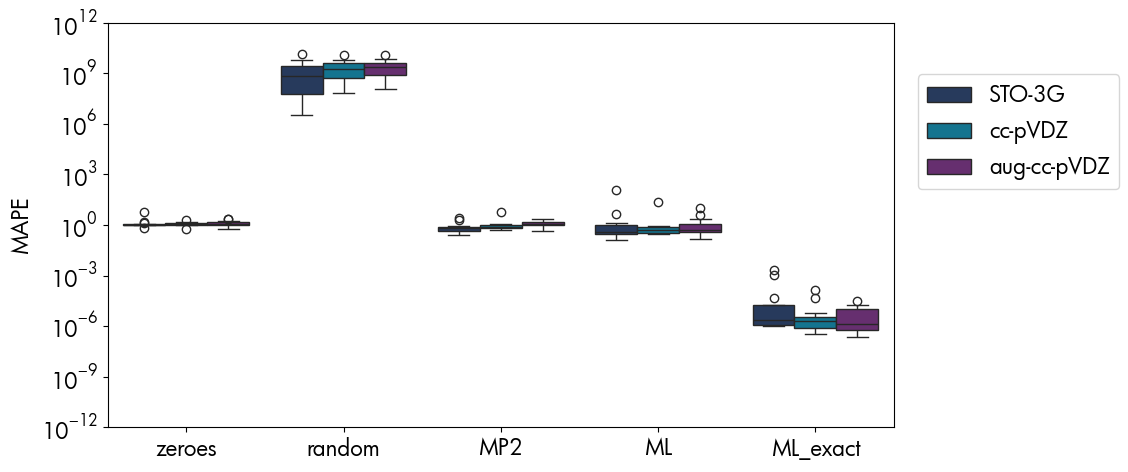

In [6]:
plt.figure(figsize=(12,5))
sns.boxplot(stackeddf,x='Injection',y='MAPE',hue='Basis',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette[0:3],order=['zeroes','random','MP2','ML','ML_exact'])
plt.yscale("log")
plt.ylim(10**-12,10**12)
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.3, 0.9))
plt.tight_layout()
plt.savefig("./GMJ_figures/AmpMapeBoxplot.png",dpi=300,bbox_inches='tight')
plt.show()

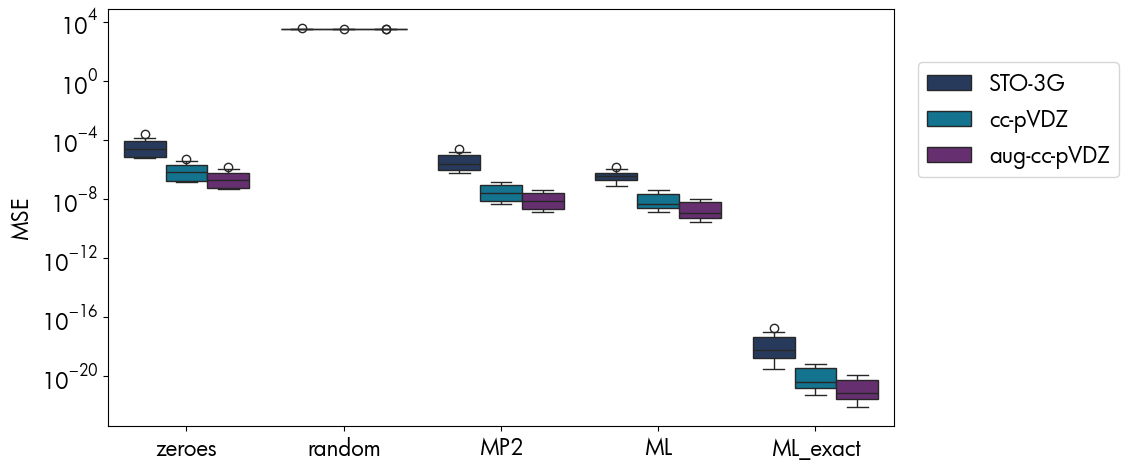

In [7]:
plt.figure(figsize=(12,5))
sns.boxplot(stackeddf,x='Injection',y='MSE',hue='Basis',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette[0:3],order=['zeroes','random','MP2','ML','ML_exact'])
plt.yscale("log")
# plt.ylim(10**-12,10**12)
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.3, 0.9))
plt.tight_layout()
plt.savefig("./GMJ_figures/AmpMSEBoxplot.png",dpi=300,bbox_inches='tight')
plt.show()

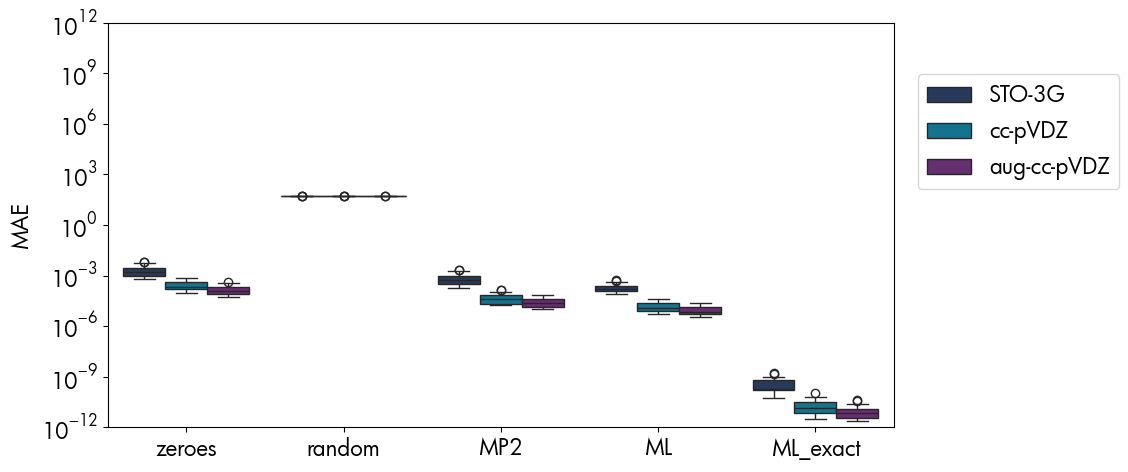

In [8]:
plt.figure(figsize=(12,5))
sns.boxplot(stackeddf,x='Injection',y='MAE',hue='Basis',hue_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette[0:3],order=['zeroes','random','MP2','ML','ML_exact'])
plt.yscale("log")
plt.ylim(10**-12,10**12)
plt.xlabel("")
plt.legend(bbox_to_anchor=(1.3, 0.9))
plt.tight_layout()
plt.savefig("./GMJ_figures/AmpMAEBoxplot.png",dpi=300,bbox_inches='tight')
plt.show()

In [9]:
for inj in ['zeroes','random','MP2','ML','ML_exact']:
    print(inj,'\n',stackeddf.loc[(stackeddf['Injection'] == inj), 'MAE'].describe().loc[['mean', 'min', 'max', 'std']].map('{:.2e}'.format))

zeroes 
 mean    9.99e-04
min     5.36e-05
max     6.49e-03
std     1.63e-03
Name: MAE, dtype: object
random 
 mean    5.01e+01
min     4.92e+01
max     5.37e+01
std     6.59e-01
Name: MAE, dtype: object
MP2 
 mean    2.95e-04
min     1.00e-05
max     2.06e-03
std     5.39e-04
Name: MAE, dtype: object
ML 
 mean    8.33e-05
min     3.42e-06
max     5.49e-04
std     1.35e-04
Name: MAE, dtype: object
ML_exact 
 mean    1.75e-10
min     2.35e-12
max     1.72e-09
std     3.88e-10
Name: MAE, dtype: object


In [10]:
stackeddf.idxmax

<bound method DataFrame.idxmax of       Amplitude           MAE           MSE          MAPE  \
27        t2_ML  9.282113e-05  8.571678e-08  4.665559e+00   
28  t2_ML_exact  5.536432e-11  3.235454e-20  7.405693e-06   
26       t2_MP2  2.558007e-04  7.968754e-07  2.456751e+00   
25      t2_rand  4.993691e+01  3.328739e+03  1.435084e+10   
24    t2_zeroes  8.370876e-04  6.933104e-06  6.318411e+00   
..          ...           ...           ...           ...   
75        t2_ML  3.344649e-05  2.706496e-08  3.251183e-01   
76  t2_ML_exact  4.849696e-11  5.311627e-20  1.697700e-06   
74       t2_MP2  1.024151e-04  1.407169e-07  5.361762e-01   
73      t2_rand  5.024851e+01  3.360337e+03  2.324655e+09   
72    t2_zeroes  6.486129e-04  5.152706e-06  5.414422e-01   

    amplitude_generation_times                    Name    Basis Injection  
27                    0.100930  (Z)-1-fluoroprop-1-ene   STO-3G        ML  
28                    0.522087  (Z)-1-fluoroprop-1-ene   STO-3G  ML_exact  
26   

In [11]:
stackeddf.loc[(stackeddf['Basis']=="STO-3G"),'MAPE'].idxmax()

np.int64(25)

In [12]:
for amp in ['zeroes','random','MP2','ML','ML_exact']:
    stats = stackeddf.loc[(stackeddf['Injection']==amp),'MAPE'].describe()
    print(amp)
    print(stats.loc[['mean','min','max','std']].map('{:.2e}'.format))
    print()

zeroes
mean    1.34e+00
min     5.41e-01
max     6.32e+00
std     9.34e-01
Name: MAPE, dtype: object

random
mean    2.91e+09
min     3.52e+06
max     1.44e+10
std     3.72e+09
Name: MAPE, dtype: object

MP2
mean    1.09e+00
min     2.46e-01
max     6.00e+00
std     9.97e-01
Name: MAPE, dtype: object

ML
mean    4.82e+00
min     1.29e-01
max     1.16e+02
std     1.94e+01
Name: MAPE, dtype: object

ML_exact
mean    9.63e-05
min     2.34e-07
max     2.04e-03
std     3.78e-04
Name: MAPE, dtype: object



In [13]:
moleculeinloop = []
for amp, basis in product(['zeroes','random','MP2','ML','ML_exact'],['STO-3G','cc-pVDZ','aug-cc-pVDZ']):
    found = stackeddf.loc[(stackeddf['Injection']==amp)&(stackeddf['Basis']==basis),'MAE']
    stats = found.describe()
    print(amp,basis)
    print(stackeddf.loc[found.idxmax(),'Name'],found.idxmax(),f"{found.max():.2e}")
    # print(stats.loc[['mean','std','min','max']].round(2))
    moleculeinloop.append(stackeddf.loc[found.idxmax(),'Name'])
    print()

freqmolmax = Counter(moleculeinloop)

zeroes STO-3G
water 30 6.49e-03

zeroes cc-pVDZ
ammonia 84 7.53e-04

zeroes aug-cc-pVDZ
ammonia 174 4.29e-04

random STO-3G
water 31 5.37e+01

random cc-pVDZ
water 73 5.02e+01

random aug-cc-pVDZ
formaldehyde 181 5.00e+01

MP2 STO-3G
water 32 2.06e-03

MP2 cc-pVDZ
methane 140 1.42e-04

MP2 aug-cc-pVDZ
ammonia 176 7.40e-05

ML STO-3G
ammonia 9 5.49e-04

ML cc-pVDZ
methane 141 3.86e-05

ML aug-cc-pVDZ
ammonia 177 2.45e-05

ML_exact STO-3G
water 34 1.72e-09

ML_exact cc-pVDZ
methane 142 1.05e-10

ML_exact aug-cc-pVDZ
methane 196 4.36e-11



In [14]:
freqmolmax

Counter({'water': 5, 'ammonia': 5, 'methane': 4, 'formaldehyde': 1})

In [15]:
stackeddf.loc[stackeddf['MAPE'].idxmin()]

Amplitude                        t2_ML_exact
MAE                                      0.0
MSE                                      0.0
MAPE                                     0.0
amplitude_generation_times         67.980082
Name                          prop-2-en-1-ol
Basis                            aug-cc-pVDZ
Injection                           ML_exact
Name: 208, dtype: object

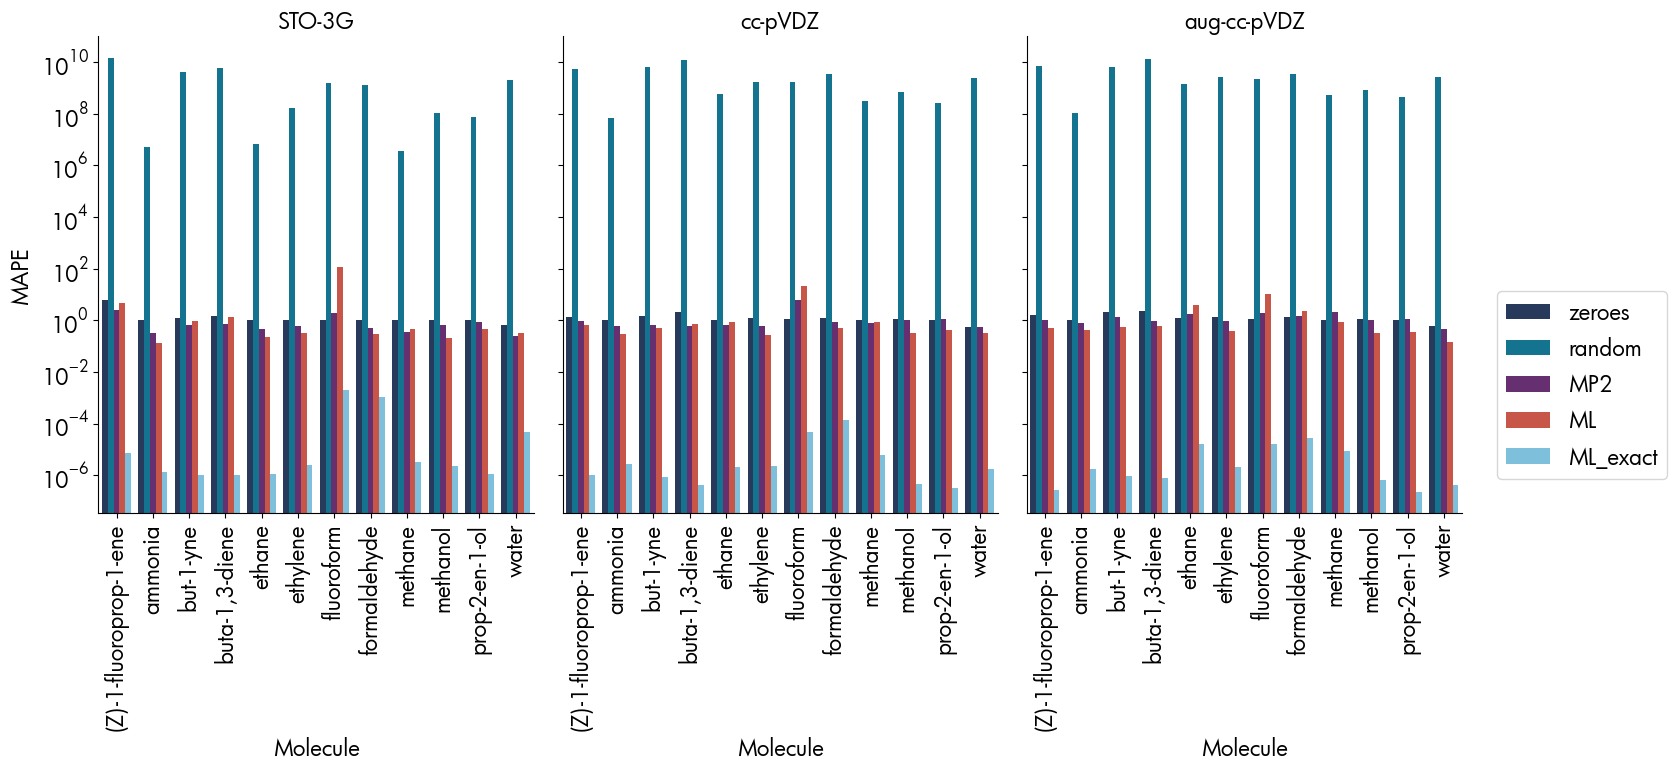

In [16]:
g = sns.catplot(stackeddf,x='Name',y='MAPE',hue='Injection',col='Basis',kind='bar',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette[0:5],hue_order=['zeroes','random','MP2','ML','ML_exact'])
for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.set_xlabel("Molecule")
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")    
g.figure.set_size_inches(15, 8)
g.set_titles(col_template="{col_name}", row_template="{row_name}") 
handles, labels = g.axes.flat[-1].get_legend_handles_labels()
g.legend.remove()
g.figure.legend(handles, labels, bbox_to_anchor=(1.00, 0.5), loc='center left')
plt.tight_layout()
plt.savefig("./GMJ_figures/AmpMapeMolecules.png",dpi=300,bbox_inches='tight')
plt.show()

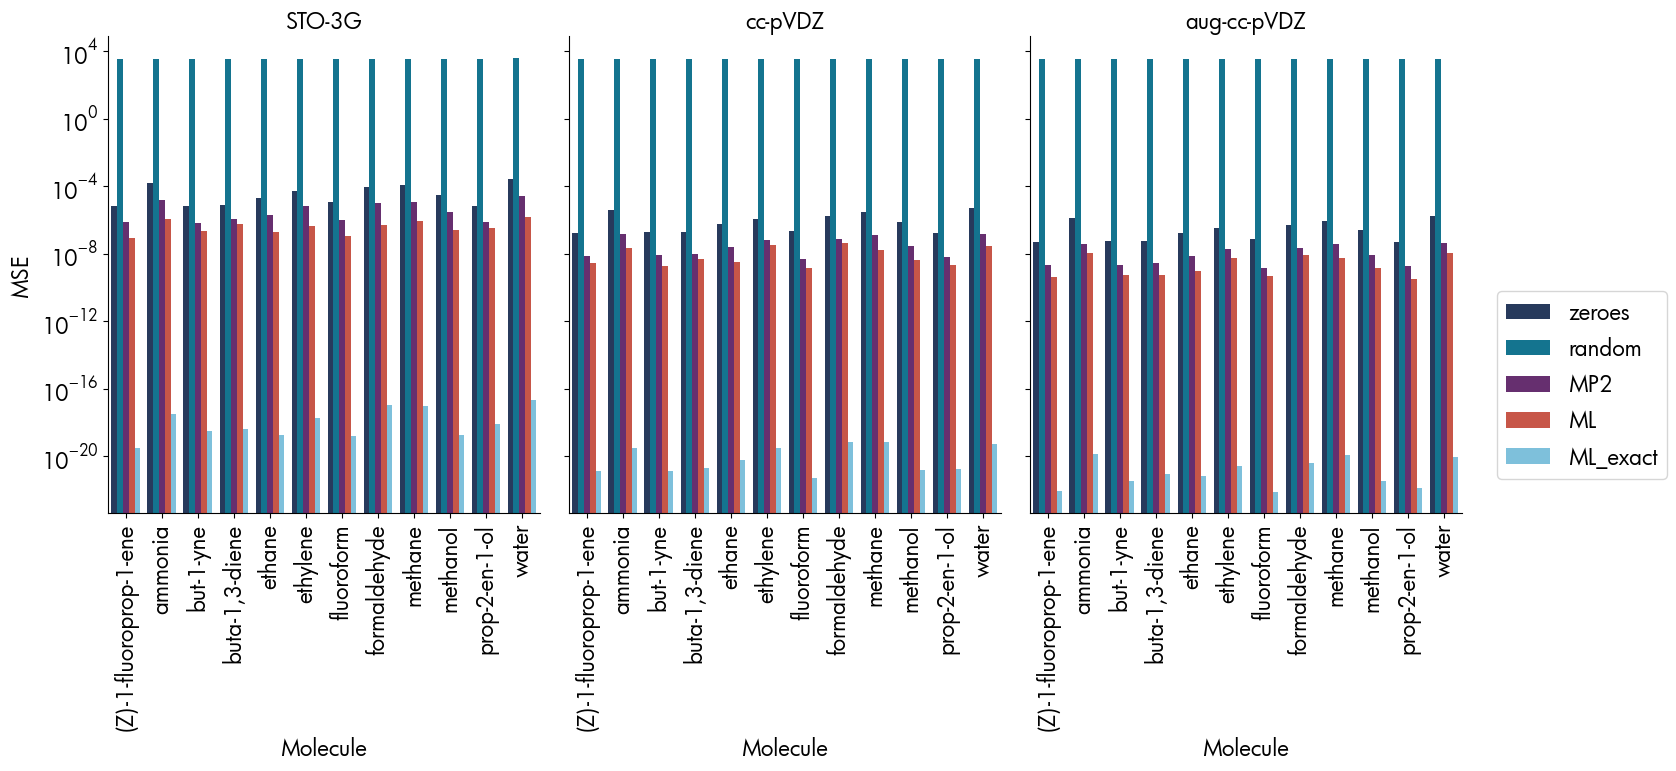

In [17]:
g = sns.catplot(stackeddf,x='Name',y='MSE',hue='Injection',col='Basis',kind='bar',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette[0:5],hue_order=['zeroes','random','MP2','ML','ML_exact'])
for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.set_xlabel("Molecule")
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")    
g.figure.set_size_inches(15, 8)
g.set_titles(col_template="{col_name}", row_template="{row_name}") 
handles, labels = g.axes.flat[-1].get_legend_handles_labels()
g.legend.remove()
g.figure.legend(handles, labels, bbox_to_anchor=(1.00, 0.5), loc='center left')
plt.tight_layout()
plt.savefig("./GMJ_figures/AmpMSEMolecules.png",dpi=300,bbox_inches='tight')
plt.show()

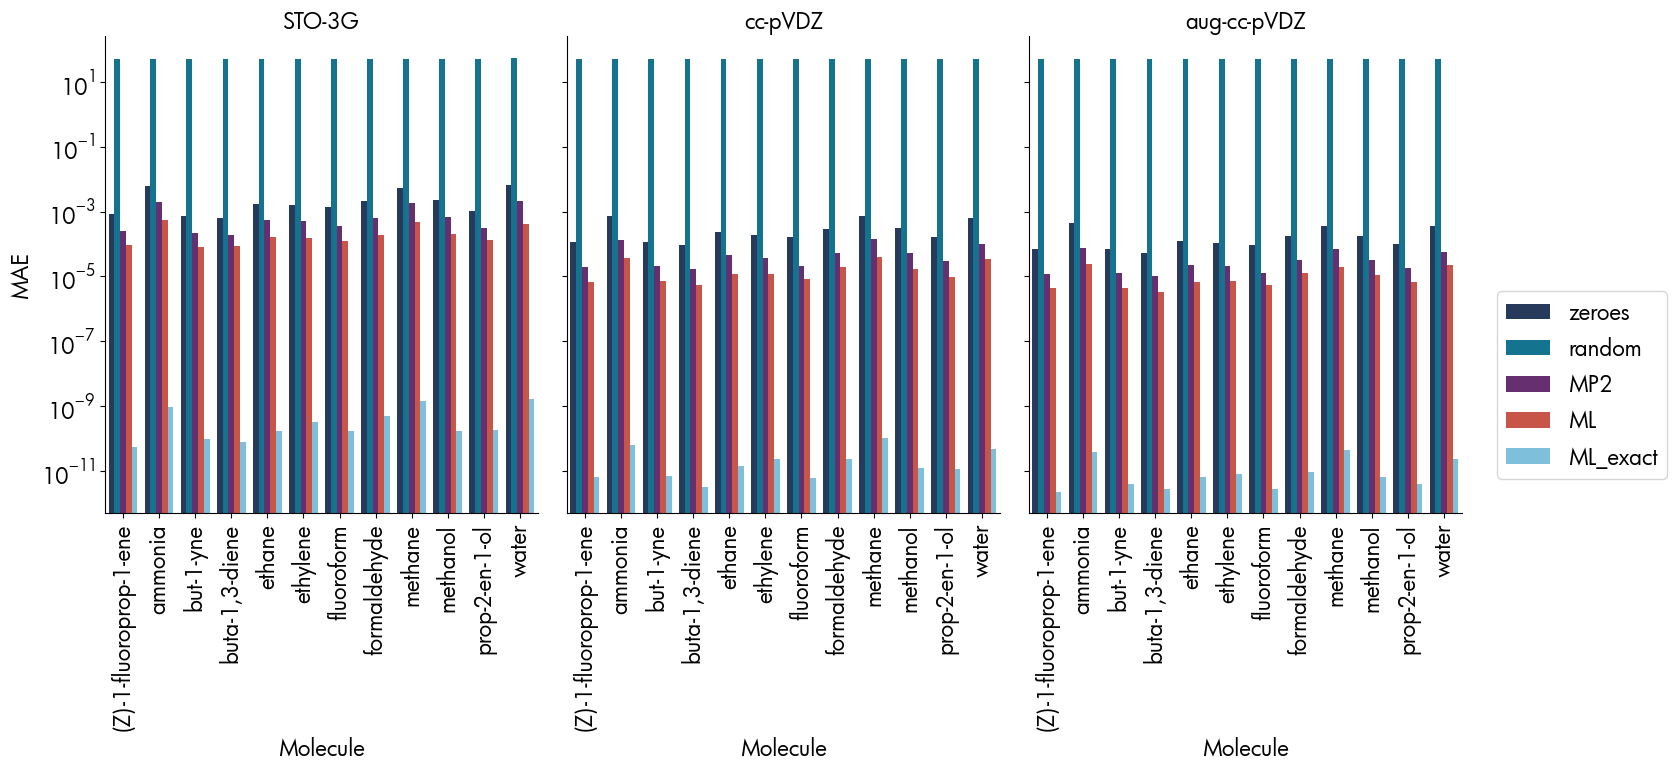

In [18]:
g = sns.catplot(stackeddf,x='Name',y='MAE',hue='Injection',col='Basis',kind='bar',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette[0:5],hue_order=['zeroes','random','MP2','ML','ML_exact'])
for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.set_xlabel("Molecule")
    for label in ax.get_xticklabels():
        # print(label)
        label.set_rotation(90)
        label.set_horizontalalignment("center")
        label.set_verticalalignment("top")    
g.figure.set_size_inches(15, 8)
g.set_titles(col_template="{col_name}", row_template="{row_name}") 
handles, labels = g.axes.flat[-1].get_legend_handles_labels()
g.legend.remove()
g.figure.legend(handles, labels, bbox_to_anchor=(1.00, 0.5), loc='center left')
plt.tight_layout()
plt.savefig("./GMJ_figures/AmpMAEMolecules.png",dpi=300,bbox_inches='tight')
plt.show()

# Compare with the Bitstring data

In [19]:
dim_df = pd.read_excel("Dimensions.xlsx",index_col=0)

In [20]:
dim_df['PostselectedPercent'] = (dim_df['Postselected'] / dim_df['Shots'])*1e2

In [21]:
n_atoms_dict = {
    'water': 3,
    'methane': 5,
    'ammonia': 4,
    'ethane': 8,
    'methanol': 6,
    'ethylene': 6,
    'formaldehyde': 4,
    "prop-2-en-1-ol":10,
    "but-1-yne":10,
    "fluoroform":5,
    "buta-1,3-diene":10,
    "(Z)-1-fluoroprop-1-ene":9
}

dim_df['n_atoms'] = dim_df['Name'].map(n_atoms_dict)

In [22]:
merged_df = stackeddf.merge(dim_df,on=['Name', 'Basis', 'Injection'],how='left')

activespacedf = pd.read_csv("../../../DDLUCJ_active_spaces_unfrozen.csv",delimiter=';')
activespacedf.rename(columns={"molecule":'Name'},inplace=True)

merged_df = merged_df.merge(activespacedf, on=['Name'],how='left')

In [24]:
dim_df

,Name,L,Basis,Injection,Postselected,Device,Exact,Shots,NOrb,Nelec,PostselectedPercent,n_atoms
0,(Z)-1-fluoroprop-1-ene,1,STO-3G,CCSD,133,10000,4173746850625,10000,25,32,1.33,9
1,(Z)-1-fluoroprop-1-ene,1,STO-3G,ML,86,10000,4173746850625,10000,25,32,0.86,9
2,(Z)-1-fluoroprop-1-ene,1,STO-3G,ML_exact,99,10000,4173746850625,10000,25,32,0.99,9
3,(Z)-1-fluoroprop-1-ene,1,STO-3G,MP2,38,10000,4173746850625,10000,25,32,0.38,9
4,(Z)-1-fluoroprop-1-ene,1,STO-3G,random,80,10000,4173746850625,10000,25,32,0.80,9
...,...,...,...,...,...,...,...,...,...,...,...,...
1075,water,5,cc-pVDZ,ML,243,5165,441,10000,7,10,2.43,3
1076,water,5,cc-pVDZ,ML_exact,245,5150,441,10000,7,10,2.45,3
1077,water,5,cc-pVDZ,MP2,198,3609,441,10000,7,10,1.98,3
1078,water,5,cc-pVDZ,random,405,6248,441,10000,7,10,4.05,3


/tmp/ipykernel_20884/2944674364.py:1: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(merged_df.sort_values(by=["Basis","n_atoms","L"]),x='Injection',y='Postselected',hue='L',col='Basis',kind='box',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette,row_order=['zeroes','random','MP2','ML','ML_exact'])


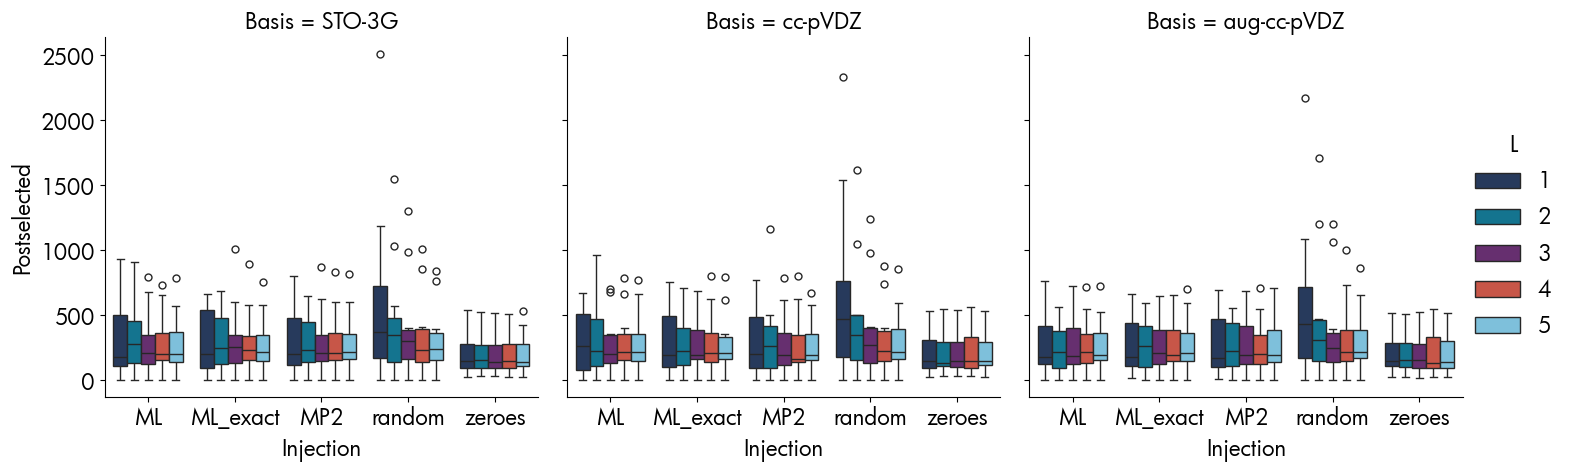

In [25]:

g = sns.catplot(merged_df.sort_values(by=["Basis","n_atoms","L"]),x='Injection',y='Postselected',hue='L',col='Basis',kind='box',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette,row_order=['zeroes','random','MP2','ML','ML_exact'])


/tmp/ipykernel_20884/1109527157.py:1: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  g = sns.catplot(merged_df.sort_values(by=["Basis","n_atoms","L"]),x='Injection',y='Device',hue='L',col='Basis',kind='box',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette,row_order=['zeroes','random','MP2','ML','ML_exact'])


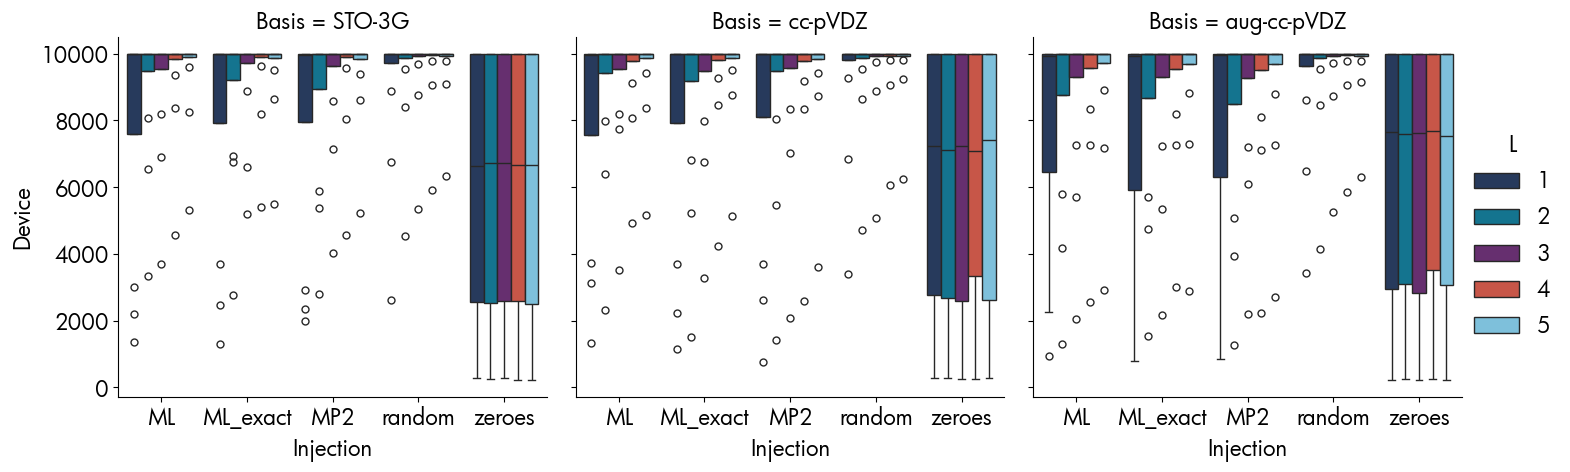

In [26]:

g = sns.catplot(merged_df.sort_values(by=["Basis","n_atoms","L"]),x='Injection',y='Device',hue='L',col='Basis',kind='box',col_order=['STO-3G','cc-pVDZ','aug-cc-pVDZ'],palette=palette,row_order=['zeroes','random','MP2','ML','ML_exact'])